In [1]:
# Official packages
import os
import copy
import math
import re
import time

from pprint import pprint
from itertools import chain

# Third-party packages
import numpy as np
import scipy

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm


import pyopencl as cl
for item in cl.get_platforms():
    print(item.get_devices())

import pynufft
device_list = pynufft.helper.device_list()
for item in device_list:
    print(item)
    
# In-house packages
from BrukerPV360 import BrukerPV360Exp


def normalize_array(arr:np.array):
    return arr/np.max(np.abs(arr))

C:\Anaconda3\lib\site-packages\pytools\persistent_dict.py:59: UserWarning: pytools.persistent_dict: unable to import 'siphash24.siphash13', falling back to hashlib.sha256
  warn("pytools.persistent_dict: unable to import 'siphash24.siphash13', "


[<pyopencl.Device 'Intel(R) UHD Graphics' on 'Intel(R) OpenCL Graphics' at 0x2366d11ac90>]
[<pyopencl.Device '11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz' on 'Intel(R) OpenCL' at 0x2366b281500>]
[<pyopencl.Device 'Intel(R) FPGA Emulation Device' on 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x2366b283580>]
[]
No cuda device found. Check your pycuda installation.
('ocl', 0, 0, <pyopencl.Platform 'Intel(R) OpenCL Graphics' at 0x23668459810>, <pyopencl.Device 'Intel(R) UHD Graphics' on 'Intel(R) OpenCL Graphics' at 0x2366d11ac90>, <reikna.cluda.ocl.Thread object at 0x000002366E9055E0>, 64)
('ocl', 1, 0, <pyopencl.Platform 'Intel(R) OpenCL' at 0x2366d0ea790>, <pyopencl.Device '11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz' on 'Intel(R) OpenCL' at 0x2366b281500>, <reikna.cluda.ocl.Thread object at 0x000002366EBCFEE0>, 1)
('ocl', 2, 0, <pyopencl.Platform 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x2366d0ebcf0>, <pyopencl.Device 'Intel(R) FPGA Emulation Device' on 'In

(965,)


<function matplotlib.pyplot.show(close=None, block=None)>

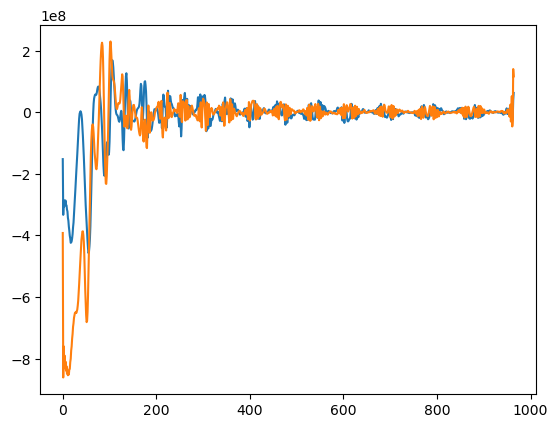

In [2]:
raw_path = "TestData\BrukerPV360\Spiral2dCoarse"

a = BrukerPV360Exp(raw_path, is_verbose=False)

FID = a.dataset['DATA']['rawdata'][0]

print(np.shape(FID))
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show

(4824,)


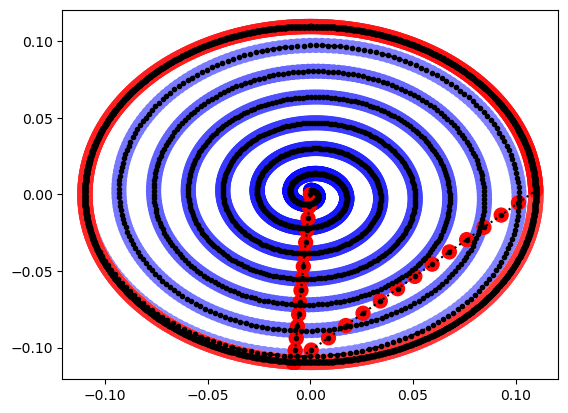

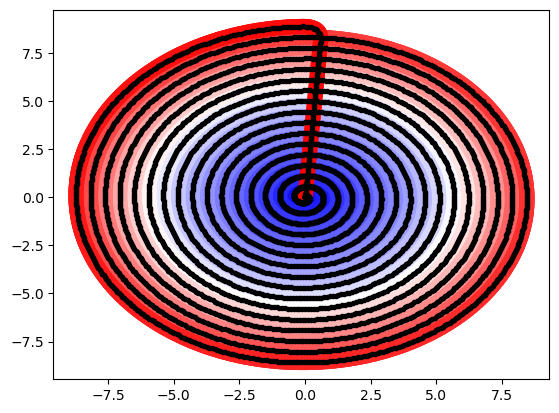

In [3]:
spiral_y = (a.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_x = (a.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])

print(np.shape(spiral_x))

plt.figure()
plt.scatter(spiral_x, spiral_y, c=(range(len(spiral_x))), s=100, cmap='bwr')
plt.plot(spiral_x, spiral_y, c= "black", marker='.', linestyle=':')
plt.show()

traj_cal_x = np.cumsum(spiral_x)
traj_cal_y = np.cumsum(spiral_y)

plt.figure()
plt.scatter(traj_cal_x, traj_cal_y, c=(range(len(traj_cal_y))), s=100, cmap='bwr')
plt.plot(traj_cal_x, traj_cal_y, c= "black", marker='.', linestyle=':')
plt.scatter(traj_cal_x, traj_cal_y, c=(range(len(traj_cal_y))), s=100, cmap='bwr')
plt.show()


[0.00171399 0.02338203]


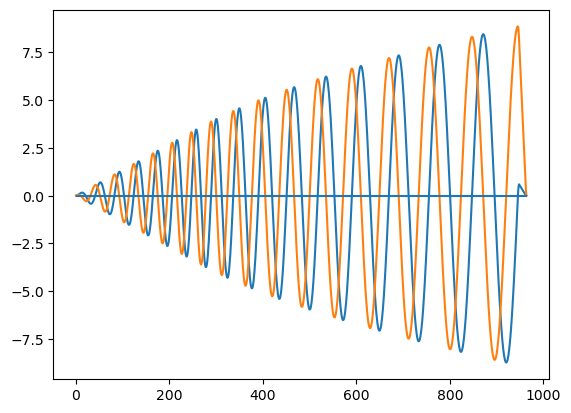

In [4]:
spiral_traj_cal = np.asarray(list(zip(traj_cal_x,traj_cal_y)))[::5]

print(spiral_traj_cal[-1])
plt.plot(spiral_traj_cal)
plt.hlines(y=0,xmin=0,xmax=len(spiral_traj_cal))

In [1]:
bruker_data = a.dataset['DATA']['2dseq']

img_shape = [int(x) for x in a.dataset['PARAM']['method'][0]['PVM_Matrix']]

NR = a.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data, cmap=cm.viridis)
plt.show()


NameError: name 'a' is not defined

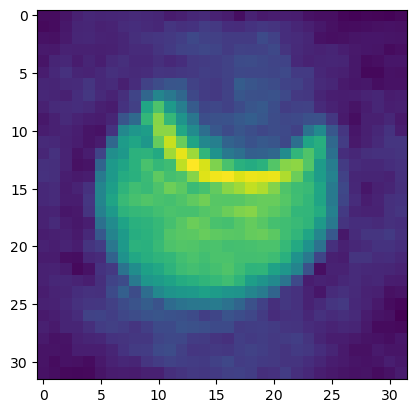

In [6]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal, Nd, Kd, Jd)

bruker_data = np.reshape(bruker_data, img_shape)
y_cal = spiralObj.forward(bruker_data)
recon = spiralObj.solve(y_cal, solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(recon.real, cmap=cm.viridis)
plt.show()


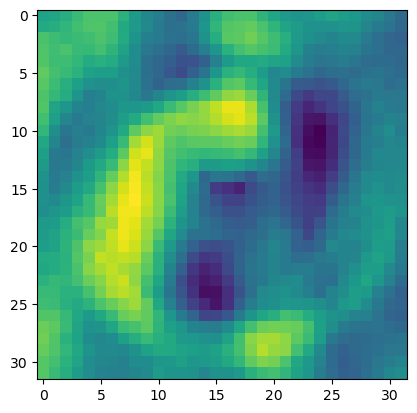

In [7]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, -1), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(recon.real, cmap=cm.viridis)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

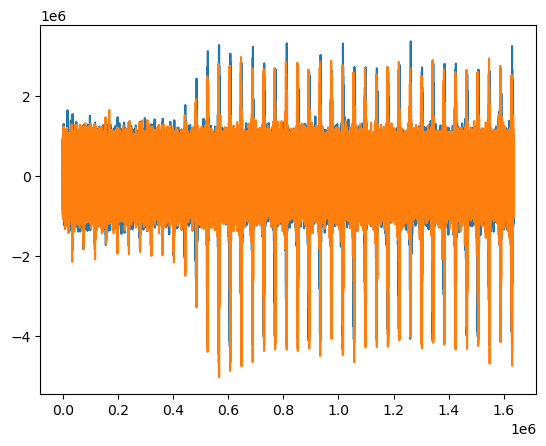

In [8]:
raw_path = 'TestData\BrukerPV360\ThermalBSsfpSpiralStack'

a = BrukerPV360Exp(raw_path, is_verbose=False)

FID = a.dataset['DATA']['rawdata'][0]


plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show

In [12]:
print(np.shape(FID))
print((a.dataset['PARAM']['method'][0]['PVM_NRepetitions']))
print((a.dataset['PARAM']['method'][0]['PVM_SpiralNbOfInterleaves']))
print((a.dataset['PARAM']['method'][0]['PVM_Matrix']))
print((a.dataset['PARAM']['method'][0]['PVM_EncMatrix']))
print((a.dataset['PARAM']['method'][0]['PVM_EncSteps2']))
print((a.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']))
print((a.dataset['PARAM']['method'][0]['PVM_SpatResol']))

(1635840,)
120
4
[20. 20. 16.]
[20. 20. 16.]
[-8. -7. -6. -5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.  7.]
213
[2.5 2.5 2.5]
